# **Classification**

### **MNIST Dataset Classification**

In [1]:
from sklearn.datasets import fetch_openml
import matplotlib
import matplotlib.pyplot as plt

mnist = fetch_openml("mnist_784", version=1, as_frame=False)


In [2]:
X, y = mnist.data, mnist.target
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


```
%matplotlib inline
```

What %matplotlib inline Does

It tells Jupyter:

 “Render all matplotlib figures inside the notebook.”

So plots appear immediately below the cell.

In [3]:
print(matplotlib.colormaps)

ColormapRegistry; available colormaps:
'magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 

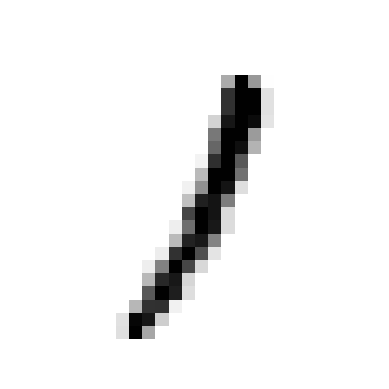

In [4]:
some_digit = X[99]
some_digit_image = some_digit.reshape(28, 28)
# matplotlib.cm             cm means color-map

%matplotlib inline
plt.imshow(some_digit_image, cmap=matplotlib.cm.binary, interpolation="nearest")
plt.axis("off")
plt.show()

In [5]:
y = y.astype(int)

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train: ", X_train.shape)
print("X_test: ",X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ",y_test.shape)

X_train:  (56000, 784)
X_test:  (14000, 784)
y_train: (56000,)
y_test:  (14000,)


# **Training a Binary Classifier**

In [7]:
y_train_1 = (y_train == 1)
y_test_1 = (y_test == 1)

In [8]:
import numpy as np
print(type(y[0]))
print(np.unique(y))

<class 'numpy.int64'>
[0 1 2 3 4 5 6 7 8 9]


In [9]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42, n_jobs=-1)
sgd_clf.fit(X_train, y_train_1)


SGDClassifier(n_jobs=-1, random_state=42)

In [10]:
sgd_clf.predict([some_digit])

array([ True])

# **Performance Measures**

### **Measuring Accuracy Using Cross-Validation**

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skf = StratifiedKFold(n_splits=3)

for train_index, test_index in skf.split(X_train, y_train_1):

  sdg_clone = clone(sgd_clf)
  X_train_folds = X_train[train_index]
  y_train_folds = (y_train_1[train_index])

  X_test_fold = X_train[test_index]
  y_test_fold = (y_train_1[test_index])

  sdg_clone.fit(X_train_folds, y_train_folds)
  y_pred = sdg_clone.predict(X_test_fold)
  n_correct = sum(y_pred == y_test_fold)

  print(n_correct / len(y_pred))


0.9907858788235925
0.9885894894734023
0.9886424515161256


In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_1, cv=3, scoring='accuracy')

array([0.99078588, 0.98858949, 0.98864245])

**dummy classifier**

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class Never1Classifier(BaseEstimator):
  def fit(self, X, y=None):
    pass
  def predict(self, X):
    return np.zeros((len(X), 1), dtype=bool)


In [ ]:
n5c = Never1Classifier()
cross_val_score(n5c, X_train, y_train_1, cv=3, scoring="accuracy")

array([0.88894841, 0.88766272, 0.88712097])

```
Why this is misleading

Suppose there are 1000 images:

910 are not 5
90 are 5

Your classifier predicts not 5 for all 1000.

Then:

it gets all 910 non-5 images correct
it gets all 90 five-images wrong
```


```
This example teaches an important machine learning lesson:

Accuracy alone is not enough for imbalanced classification.

For this problem, better metrics are:

precision
recall
F1 score
confusion matrix
```


# **Confusion Matrix**

In [ ]:
from sklearn.model_selection import cross_val_predict

y_train_pred =  cross_val_predict(sgd_clf, X_train, y_train_1, cv=3, n_jobs=-1)


In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_1, y_train_pred)


array([[49381,   342],
       [  255,  6022]])

In [ ]:
from sklearn.metrics import precision_score, recall_score

print(precision_score(y_train_1, y_train_pred))

print(recall_score(y_train_1, y_train_pred))

0.9462602137020741
0.9593754978492911


In [ ]:
from sklearn.metrics import f1_score

print(f1_score(y_train_1, y_train_pred))

0.9527727236769243


# **Precision/Recall Tradeoff**
```
Imagine a Security Guard

Suppose a guard checks people entering a building.

The guard must detect:

criminals = Positive class
innocent people = Negative class

The guard uses a confidence score.

STRICT Guard

The guard says:

“I will only arrest someone if I am VERY sure.”

This is like using a HIGH threshold.

Example:

threshold = 30000

Result:

very few innocent people arrested
but many criminals escape
Metrics
Precision becomes HIGH

Because:

when guard says “criminal”
he is usually correct
Recall becomes LOW

Because:

many real criminals were missed
RELAXED Guard

The guard says:

“I will arrest anyone slightly suspicious.”

This is LOW threshold.

Example:

threshold = -10000

Result:

catches almost all criminals
but many innocent people arrested
Metrics
Recall becomes HIGH

Because:

most real criminals caught
Precision becomes LOW

Because:

many false alarms
THIS IS THE TRADEOFF

You usually cannot maximize BOTH simultaneously.

Increasing one often decreases the other.
```

## **Decision Function:**

In [ ]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2542.70735601])

if the confidence is greater than threshold then classify it as a true

```
y_pred = (sgd_clf.decision_function([some_digit]) > threshold)
```

In [ ]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [ ]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_1, cv=3,
method="decision_function")

In [ ]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_train_1, y_scores)
# Internally It Does predict = (y_scores > threshold) for many threshold


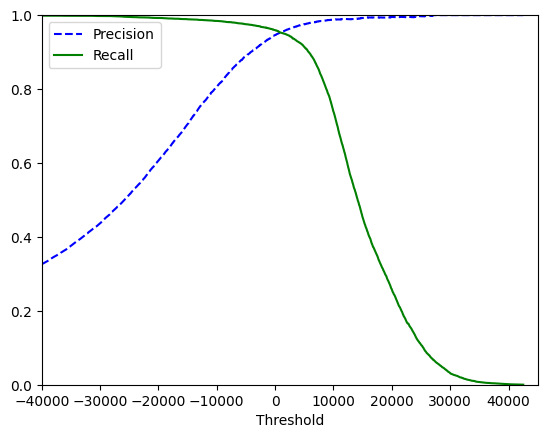

In [ ]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds=0):
  plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
  plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
  plt.xlabel("Threshold")
  plt.legend(loc='upper left')
  plt.ylim([0,1])
  plt.xlim([-40000,45000])

plot_precision_recall_vs_threshold(precision, recall, thresholds)
plt.show()

### **Plot Precision vs Recall**

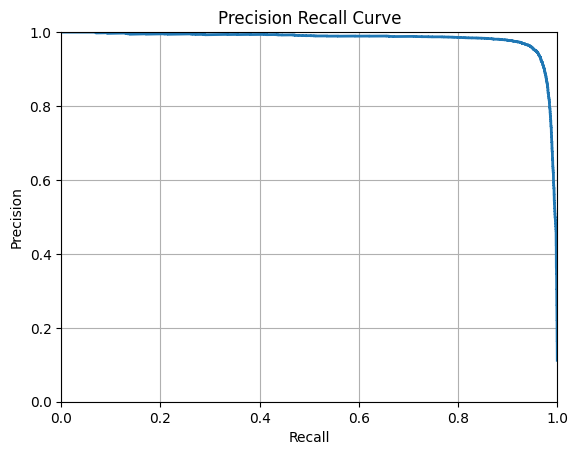

In [ ]:
plt.plot(recall, precision, linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.xlim([0,1])
plt.ylim([0,1])

plt.grid(True)

plt.show()

### **LOWER THRESHOLD TO INCREASE RECALL**

In [ ]:
custom_threshold = -10000

y_train_pred_high_recall = (y_scores > custom_threshold)

print("\nLOWER THRESHOLD RESULTS")
print("Threshold:", custom_threshold)

print("Precision:", precision_score(y_train_1, y_train_pred_high_recall))

print("Recall:", recall_score(y_train_1, y_train_pred_high_recall))



LOWER THRESHOLD RESULTS
Threshold: -10000
Precision: 0.8068434112576727
Recall: 0.9842281344591365


### **HIGHER THRESHOLD TO INCREASE PRECISION**

In [ ]:
custom_threshold = 10000

y_train_pred_high_precision = (y_scores > custom_threshold)

print("HIGHER THRESHOLD RESULTS")
print("Threshold:", custom_threshold)

print("Precision:", precision_score(y_train_1, y_train_pred_high_precision))

print("Recall:", recall_score(y_train_1, y_train_pred_high_recall))


HIGHER THRESHOLD RESULTS
Threshold: 10000
Precision: 0.9876438005965061
Recall: 0.9842281344591365


# **The ROC Curve**

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_1, y_scores)


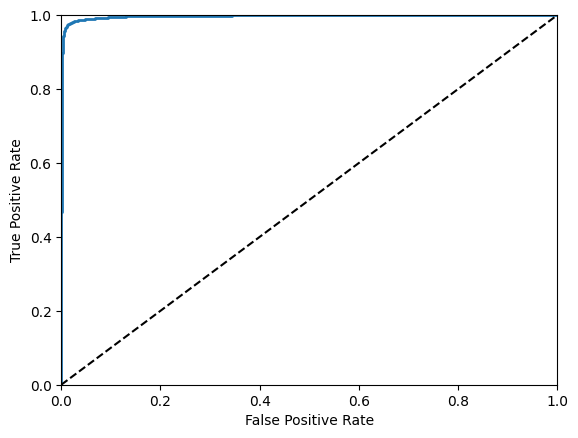

In [ ]:
def plot_roc_curve(fpr, tpr, label):
  plt.plot(fpr, tpr, linewidth=2, label=label)
  plt.plot([0, 1], [0, 1], 'k--')
  plt.axis([0, 1, 0, 1])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')

plot_roc_curve(fpr, tpr, "The ROC cruve")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_1, y_scores)

np.float64(0.9969977373870617)

**RandomForestClassifier and compare its ROC curve and ROC AUC score to the SGDClassifier.**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_cls = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_cls, X_train, y_train_1, cv=3, method="predict_proba")

In [ ]:
y_probas_forest

array([[1.  , 0.  ],
       [1.  , 0.  ],
       [0.9 , 0.1 ],
       ...,
       [0.02, 0.98],
       [1.  , 0.  ],
       [1.  , 0.  ]])

In [ ]:
y_scores_forest = y_probas_forest[:, 1]
y_scores_forest

array([0.  , 0.  , 0.1 , ..., 0.98, 0.  , 0.  ])

In [ ]:
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_1,y_scores_forest)

### **Comparing ROC curves**

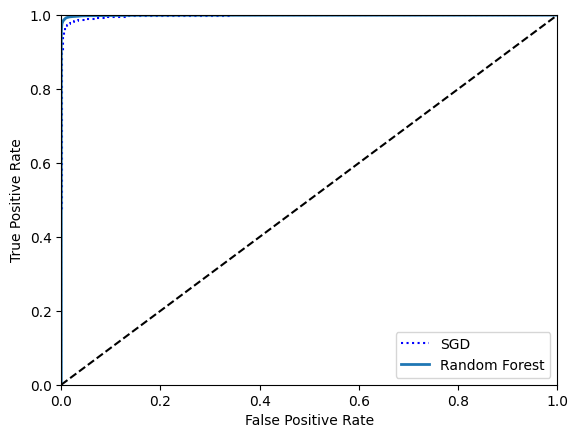

In [ ]:
plt.plot(fpr, tpr, "b:", label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right")
plt.show()

In [ ]:
roc_auc_score(y_train_1, y_scores_forest)

np.float64(0.9994120029712096)

# **Multiclass Classification**

In [ ]:
sgd_clf.fit(X_train, y_train)

SGDClassifier(n_jobs=-1, random_state=42)

In [ ]:
sgd_clf.predict([some_digit])

array([1])

In [ ]:
some_digit_scores = sgd_clf.decision_function([some_digit])
some_digit_scores

array([[-29539.95837246,   8485.32808009,  -4057.50284179,
          -511.6170552 ,  -6488.27704837,  -9141.27382922,
        -19837.77908246,  -1448.9407357 ,  -3164.73503798,
         -2008.95371169]])

In [ ]:
np.argmax(some_digit_scores)

np.int64(1)

In [ ]:
sgd_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
sgd_clf.classes_[5]

np.int64(5)

In [ ]:
from sklearn.multiclass import OneVsOneClassifier
ovo_clf = OneVsOneClassifier(SGDClassifier(random_state=42))
ovo_clf.fit(X_train, y_train)
ovo_clf.predict([some_digit])

array([1])

In [ ]:
len(ovo_clf.estimators_)

45

In [ ]:
forest_cls.fit(X_train, y_train)
forest_cls.predict([some_digit])

array([1])

In [ ]:
forest_cls.predict_proba([some_digit])

array([[0.  , 0.99, 0.01, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]])

In [ ]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.84212782, 0.87416296, 0.83129755])

In [ ]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

X_train_ss = ss.fit_transform(X_train.astype(np.float64))

cross_val_score(sgd_clf, X_train_ss, y_train, cv=3, scoring="accuracy")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.91059088, 0.90625167, 0.90147862])

# **Error Analysis**

In [ ]:
y_train_pred = cross_val_predict(sgd_clf, X_train_ss, y_train, cv=3)
conf_mx = confusion_matrix(y_train, y_train_pred)
conf_mx

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([[5290,    0,   15,    8,    8,   38,   40,    6,  154,    1],
       [   1, 5996,   42,   15,    3,   35,    8,   10,  155,   12],
       [  26,   28, 4982,   79,   65,   26,   56,   43,  289,   16],
       [  23,   18,  117, 4951,    2,  188,   23,   38,  288,   60],
       [  11,   17,   43,    6, 4986,   12,   43,   27,  213,  171],
       [  37,   16,   26,  148,   45, 4222,   83,   21,  369,   73],
       [  29,   17,   54,    2,   41,   89, 5134,    4,  110,    0],
       [  18,   16,   64,   20,   44,   10,    5, 5282,  103,  228],
       [  20,   59,   45,   79,    3,  130,   28,    7, 5043,   54],
       [  25,   17,   24,   60,  128,   35,    1,  149,  243, 4856]])

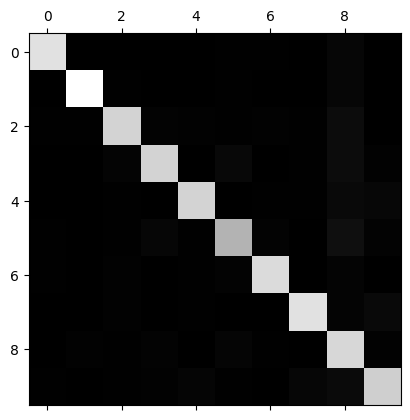

In [ ]:
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

In [ ]:
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums

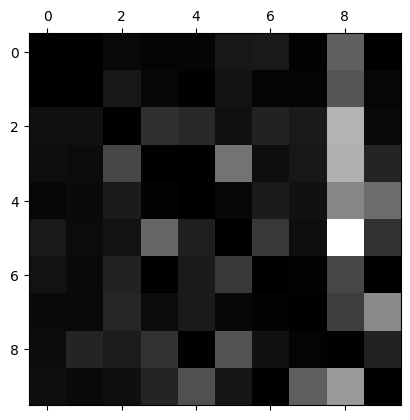

In [ ]:
np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.show()

In [ ]:
cl_a, cl_b = 8, 9
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]


In [28]:
def plot_digits(instances, images_per_row=5):
  size = 28

  images_per_row = min(len(instances), images_per_row)

  images = [instance.reshape(size, size) for instance in instances]

  n_rows = (len(instances) - 1) // images_per_row + 1

  row_images = []

  for row in range(n_rows):
    row_imgs = images[row * images_per_row : (row + 1) * images_per_row]

    while len(row_imgs) < images_per_row:
      row_imgs.append(np.zeros((size, size)))

    row_images.append(np.concatenate(row_imgs, axis=1))

  image = np.concatenate(row_images, axis=0)

  plt.imshow(image, cmap="binary")
  plt.axis("off")

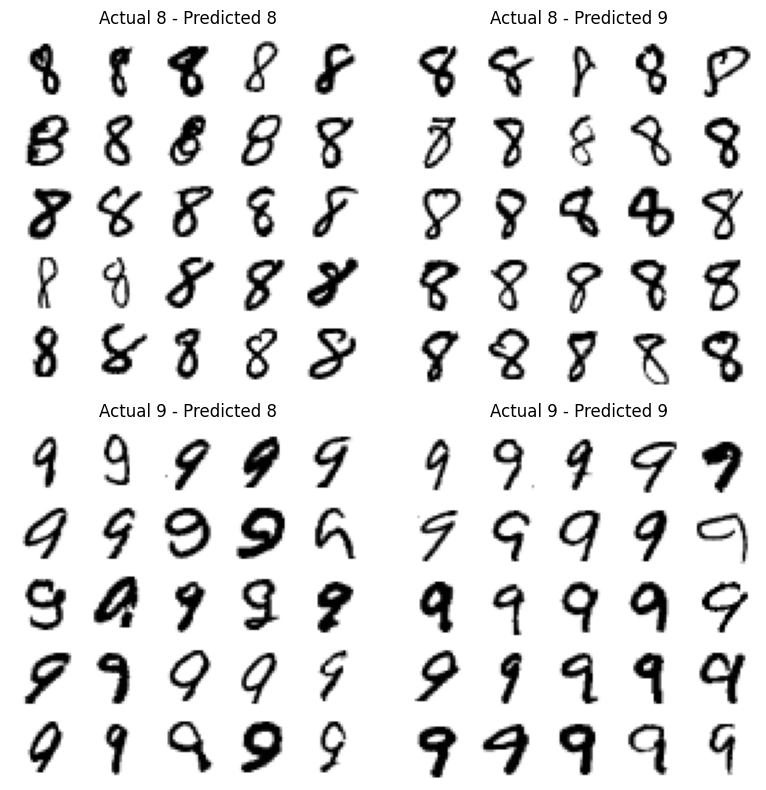

In [ ]:
plt.figure(figsize=(8,8))

# Correctly classified 3s
plt.subplot(221)
plot_digits(X_aa[:25], images_per_row=5)
plt.title("Actual 8 - Predicted 8")

# 3s classified as 5s
plt.subplot(222)
plot_digits(X_ab[:25], images_per_row=5)
plt.title("Actual 8 - Predicted 9")

# 5s classified as 3s
plt.subplot(223)
plot_digits(X_ba[:25], images_per_row=5)
plt.title("Actual 9 - Predicted 8")

# Correctly classified 5s
plt.subplot(224)
plot_digits(X_bb[:25], images_per_row=5)
plt.title("Actual 9 - Predicted 9")

plt.tight_layout()
plt.show()

# **Multilabel Classification**

In [11]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)

y_multilabel = np.c_[y_train_large, y_train_odd]

print(y_train_large)
print(y_train_odd)
print(y_multilabel)

[False False  True ... False False False]
[ True False False ...  True False False]
[[False  True]
 [False False]
 [ True False]
 ...
 [False  True]
 [False False]
 [False False]]


In [12]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

KNeighborsClassifier()

In [13]:
knn_clf.predict([some_digit])

array([[False,  True]])

In [15]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score

y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)

In [16]:
score = f1_score(y_multilabel, y_train_knn_pred, average="macro")
print(score)

0.9759770524441204


# **Multioutput Classification**

In [23]:
import numpy as np

np.random.seed(42)

noise_train = np.random.randint(0, 100, (len(X_train), 784))
noise_test = np.random.randint(0, 100, (len(X_test), 784))

X_train_mod = X_train + noise_train
X_test_mod = X_test + noise_test

y_train_mod = X_train
y_test_mod = X_test

In [25]:
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[20]])

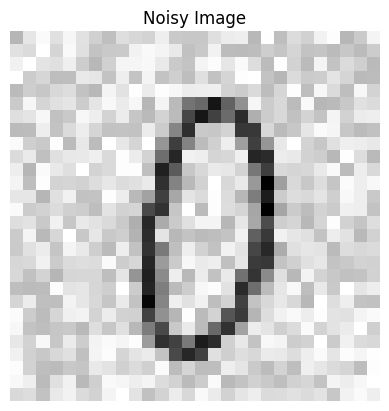

In [35]:
plt.imshow(X_test_mod[20].reshape(28,28), cmap="binary")
plt.title("Noisy Image")
plt.axis("off")
plt.show()

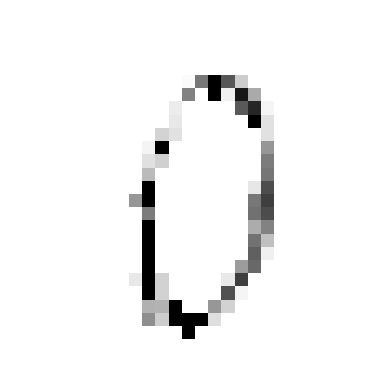

In [37]:
plt.imshow(clean_digit.reshape(28,28), cmap="binary")
plt.axis("off")
plt.show()